Sentiment Analysis


---
## 1 · Install & Setup

In [1]:
%%capture
!pip install transformers datasets evaluate kaggle scikit-learn accelerate \
             wordcloud nltk matplotlib seaborn plotly

In [2]:
import warnings, os, re, glob
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('punkt',     quiet=True)
from nltk.corpus   import stopwords
from nltk.stem     import WordNetLemmatizer
from wordcloud     import WordCloud, STOPWORDS

STOP = set(stopwords.words('english')) | set(STOPWORDS)
LMT  = WordNetLemmatizer()

# Plotting style
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
PALETTE = {'positive': '#2ecc71', 'neutral': '#3498db', 'negative': '#e74c3c'}

print('Libraries loaded')

Libraries loaded


---
## 2 · Download Dataset from Kaggle

1. Visit [kaggle.com/settings](https://www.kaggle.com/settings) → **API → Create New Token** → download `kaggle.json`
2. Upload it when the cell below prompts you

In [3]:
from google.colab import files

print('Upload kaggle.json ➜')
uploaded = files.upload()
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
os.replace('kaggle.json', os.path.expanduser('~/.kaggle/kaggle.json'))
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)
print('Kaggle credentials configured!')

Upload kaggle.json ➜


Saving kaggle.json to kaggle.json
Kaggle credentials configured!


In [4]:
!kaggle datasets download -d abhi8923shriv/sentiment-analysis-dataset --unzip -p ./data
print('\nFiles in ./data:')
!ls -lh ./data

Dataset URL: https://www.kaggle.com/datasets/abhi8923shriv/sentiment-analysis-dataset
License(s): CC0-1.0
100% 54.4M/54.4M [00:00<00:00, 163MB/s]


Files in ./data:
total 144M
-rw-r--r-- 1 root root 463K Apr 17 16:10 test.csv
-rw-r--r-- 1 root root  70K Apr 17 16:10 testdata.manual.2009.06.14.csv
-rw-r--r-- 1 root root 4.5M Apr 17 16:10 train.csv
-rw-r--r-- 1 root root 139M Apr 17 16:10 training.1600000.processed.noemoticon.csv


In [5]:
csv_files  = glob.glob('./data/**/*.csv', recursive=True)
train_path = next((f for f in csv_files if 'train' in f.lower()), csv_files[0])
test_path  = next((f for f in csv_files if 'test'  in f.lower()), csv_files[-1])

def load_csv(path):
    for enc in ['utf-8', 'latin-1', 'cp1252']:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception:
            pass

df_raw_train = load_csv(train_path)
df_raw_test  = load_csv(test_path)
print(f'Train : {df_raw_train.shape}  |  Test : {df_raw_test.shape}')
df_raw_train.head(3)

Train : (27481, 10)  |  Test : (4815, 9)


,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18


In [6]:
# Auto-detect text / label columns
TEXT_COL  = None
LABEL_COL = None
for col in df_raw_train.columns:
    lc = col.lower()
    if lc in ('text','tweet','sentence','review','content') and TEXT_COL  is None: TEXT_COL  = col
    if lc in ('sentiment','label','class','target','polarity') and LABEL_COL is None: LABEL_COL = col
TEXT_COL  = TEXT_COL  or df_raw_train.select_dtypes('object').columns[0]
LABEL_COL = LABEL_COL or df_raw_train.columns[-1]
print(f'Text column  → {TEXT_COL}\nLabel column → {LABEL_COL}')

Text column  → text
Label column → sentiment


---
## 3 · Deep Exploratory Data Analysis (EDA)

In [7]:
# ── 3.1  Missing values & basic stats ────────────────────────────────────────
print('=' * 55)
print('  DATASET OVERVIEW')
print('=' * 55)
print(f'  Rows          : {len(df_raw_train):,}')
print(f'  Columns       : {list(df_raw_train.columns)}')
print(f'  Missing values:\n{df_raw_train.isnull().sum()}')
print('\nDtype summary:')
print(df_raw_train.dtypes)

  DATASET OVERVIEW
  Rows          : 27,481
  Columns       : ['textID', 'text', 'selected_text', 'sentiment', 'Time of Tweet', 'Age of User', 'Country', 'Population -2020', 'Land Area (Km²)', 'Density (P/Km²)']
  Missing values:
textID              0
text                1
selected_text       1
sentiment           0
Time of Tweet       0
Age of User         0
Country             0
Population -2020    0
Land Area (Km²)     0
Density (P/Km²)     0
dtype: int64

Dtype summary:
textID               object
text                 object
selected_text        object
sentiment            object
Time of Tweet        object
Age of User          object
Country              object
Population -2020      int64
Land Area (Km²)     float64
Density (P/Km²)       int64
dtype: object


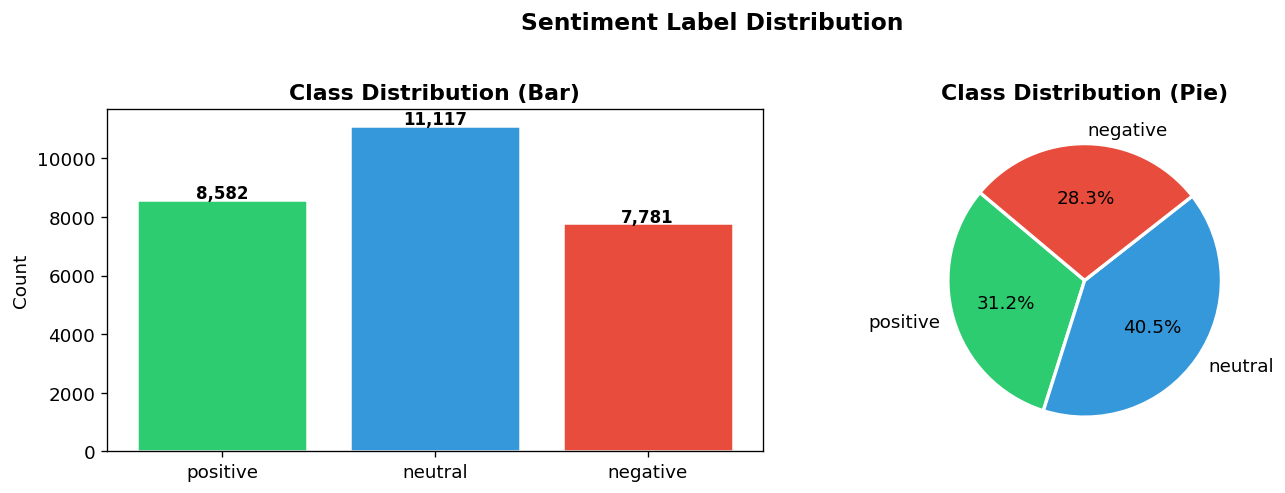


Class counts:
  positive  :  8,582  (31.2%)
  neutral   : 11,117  (40.5%)
  negative  :  7,781  (28.3%)

Imbalance ratio (max/min): 1.43x


In [8]:
# ── 3.2  Label distribution ──────────────────────────────────────────────────
def normalise_label(lbl):
    lbl = str(lbl).strip().lower()
    if lbl in ('positive','pos','1','happy','2'): return 'positive'
    if lbl in ('negative','neg','-1','sad','0'):  return 'negative'
    return 'neutral'

eda_df = df_raw_train[[TEXT_COL, LABEL_COL]].dropna().copy()
eda_df['label'] = eda_df[LABEL_COL].apply(normalise_label)

counts = eda_df['label'].value_counts().reindex(['positive','neutral','negative'])
colors = [PALETTE[l] for l in counts.index]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution (Bar)', fontweight='bold')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', fontsize=10, fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, colors=colors,
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution (Pie)', fontweight='bold')

plt.suptitle('Sentiment Label Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_class_dist.png', bbox_inches='tight', dpi=130)
plt.show()

print('\nClass counts:')
for lbl, cnt in counts.items():
    pct = cnt / counts.sum() * 100
    print(f'  {lbl:10s}: {cnt:6,}  ({pct:.1f}%)')
imb = counts.max() / counts.min()
print(f'\nImbalance ratio (max/min): {imb:.2f}x')

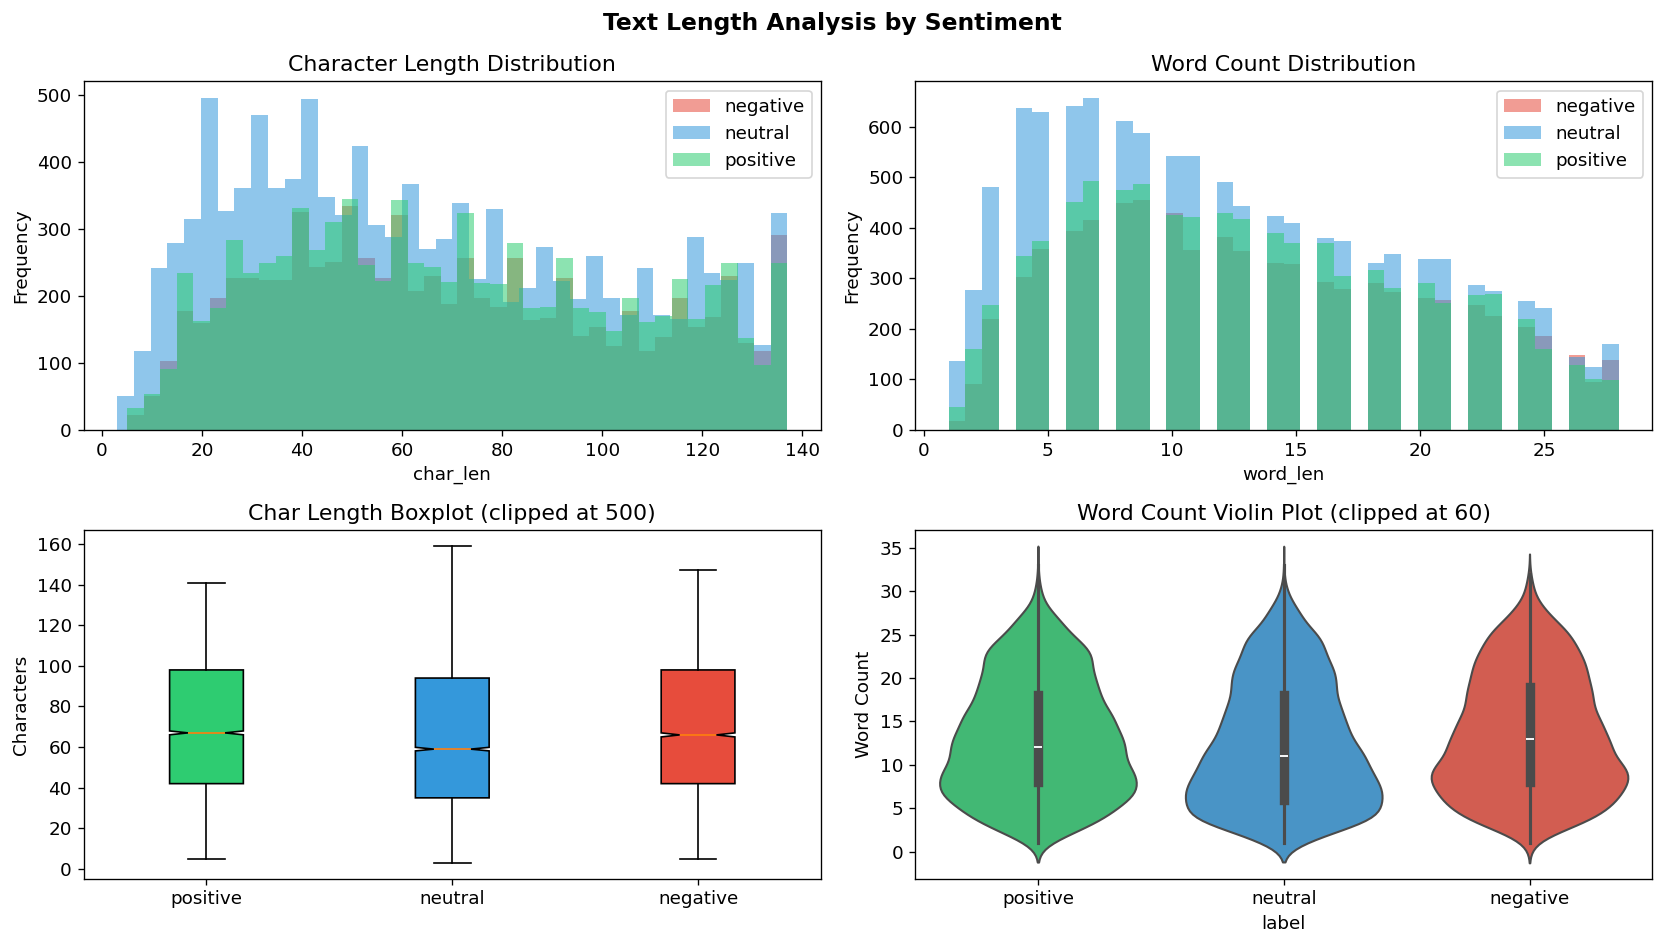


Text length stats per class (words):
            count  mean  std  min  25%   50%   75%   max
label                                                   
negative   7781.0  13.5  6.9  1.0  8.0  13.0  19.0  32.0
neutral   11117.0  12.3  7.1  1.0  6.0  11.0  18.0  33.0
positive   8582.0  13.1  6.7  1.0  8.0  12.0  18.0  33.0


In [9]:
# ── 3.3  Text-length analysis ─────────────────────────────────────────────────
eda_df['char_len'] = eda_df[TEXT_COL].astype(str).apply(len)
eda_df['word_len'] = eda_df[TEXT_COL].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Text Length Analysis by Sentiment', fontsize=14, fontweight='bold')

for ax, col, title in zip(
    [axes[0,0], axes[0,1]],
    ['char_len', 'word_len'],
    ['Character Length Distribution', 'Word Count Distribution']
):
    for lbl, grp in eda_df.groupby('label'):
        ax.hist(grp[col].clip(upper=grp[col].quantile(0.99)),
                bins=40, alpha=0.55, label=lbl, color=PALETTE[lbl], edgecolor='none')
    ax.set_title(title); ax.set_xlabel(col); ax.set_ylabel('Frequency')
    ax.legend()

# Boxplot — char length
bp_data = [eda_df[eda_df['label']==l]['char_len'].clip(upper=500).values
           for l in ['positive','neutral','negative']]
bp = axes[1,0].boxplot(bp_data, labels=['positive','neutral','negative'],
                        patch_artist=True, notch=True)
for patch, lbl in zip(bp['boxes'], ['positive','neutral','negative']):
    patch.set_facecolor(PALETTE[lbl])
axes[1,0].set_title('Char Length Boxplot (clipped at 500)')
axes[1,0].set_ylabel('Characters')

# Violin — word count
violin_df = eda_df[['label','word_len']].copy()
violin_df['word_len'] = violin_df['word_len'].clip(upper=60)
sns.violinplot(data=violin_df, x='label', y='word_len', order=['positive','neutral','negative'],
               palette=PALETTE, inner='box', ax=axes[1,1])
axes[1,1].set_title('Word Count Violin Plot (clipped at 60)')
axes[1,1].set_ylabel('Word Count')

plt.tight_layout()
plt.savefig('eda_text_length.png', bbox_inches='tight', dpi=130)
plt.show()

print('\nText length stats per class (words):')
print(eda_df.groupby('label')['word_len'].describe().round(1).to_string())

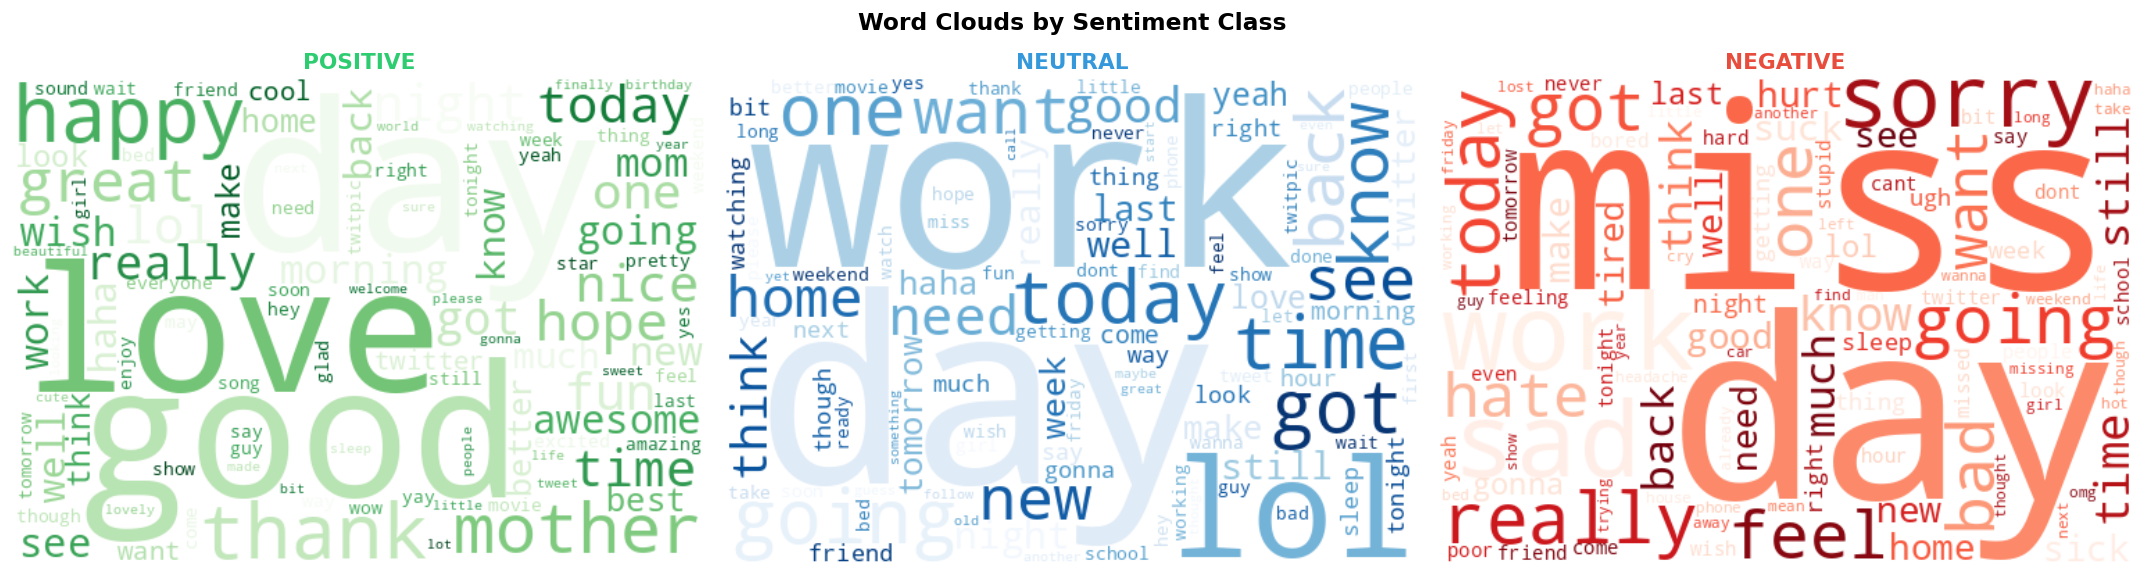

In [10]:
# ── 3.4  Per-class Word Clouds ────────────────────────────────────────────────
def get_words(texts):
    words = []
    for t in texts:
        toks = re.sub(r'[^a-zA-Z ]', ' ', str(t).lower()).split()
        words += [LMT.lemmatize(w) for w in toks if w not in STOP and len(w) > 2]
    return ' '.join(words)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Word Clouds by Sentiment Class', fontsize=14, fontweight='bold')

wc_colors = {'positive': 'Greens', 'neutral': 'Blues', 'negative': 'Reds'}

for ax, lbl in zip(axes, ['positive', 'neutral', 'negative']):
    corpus = get_words(eda_df[eda_df['label'] == lbl][TEXT_COL])
    wc = WordCloud(
        width=500, height=350,
        background_color='white',
        max_words=100,
        colormap=wc_colors[lbl],
        collocations=False
    ).generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(lbl.upper(), fontsize=13, fontweight='bold', color=PALETTE[lbl])

plt.tight_layout()
plt.savefig('eda_wordclouds.png', bbox_inches='tight', dpi=130)
plt.show()

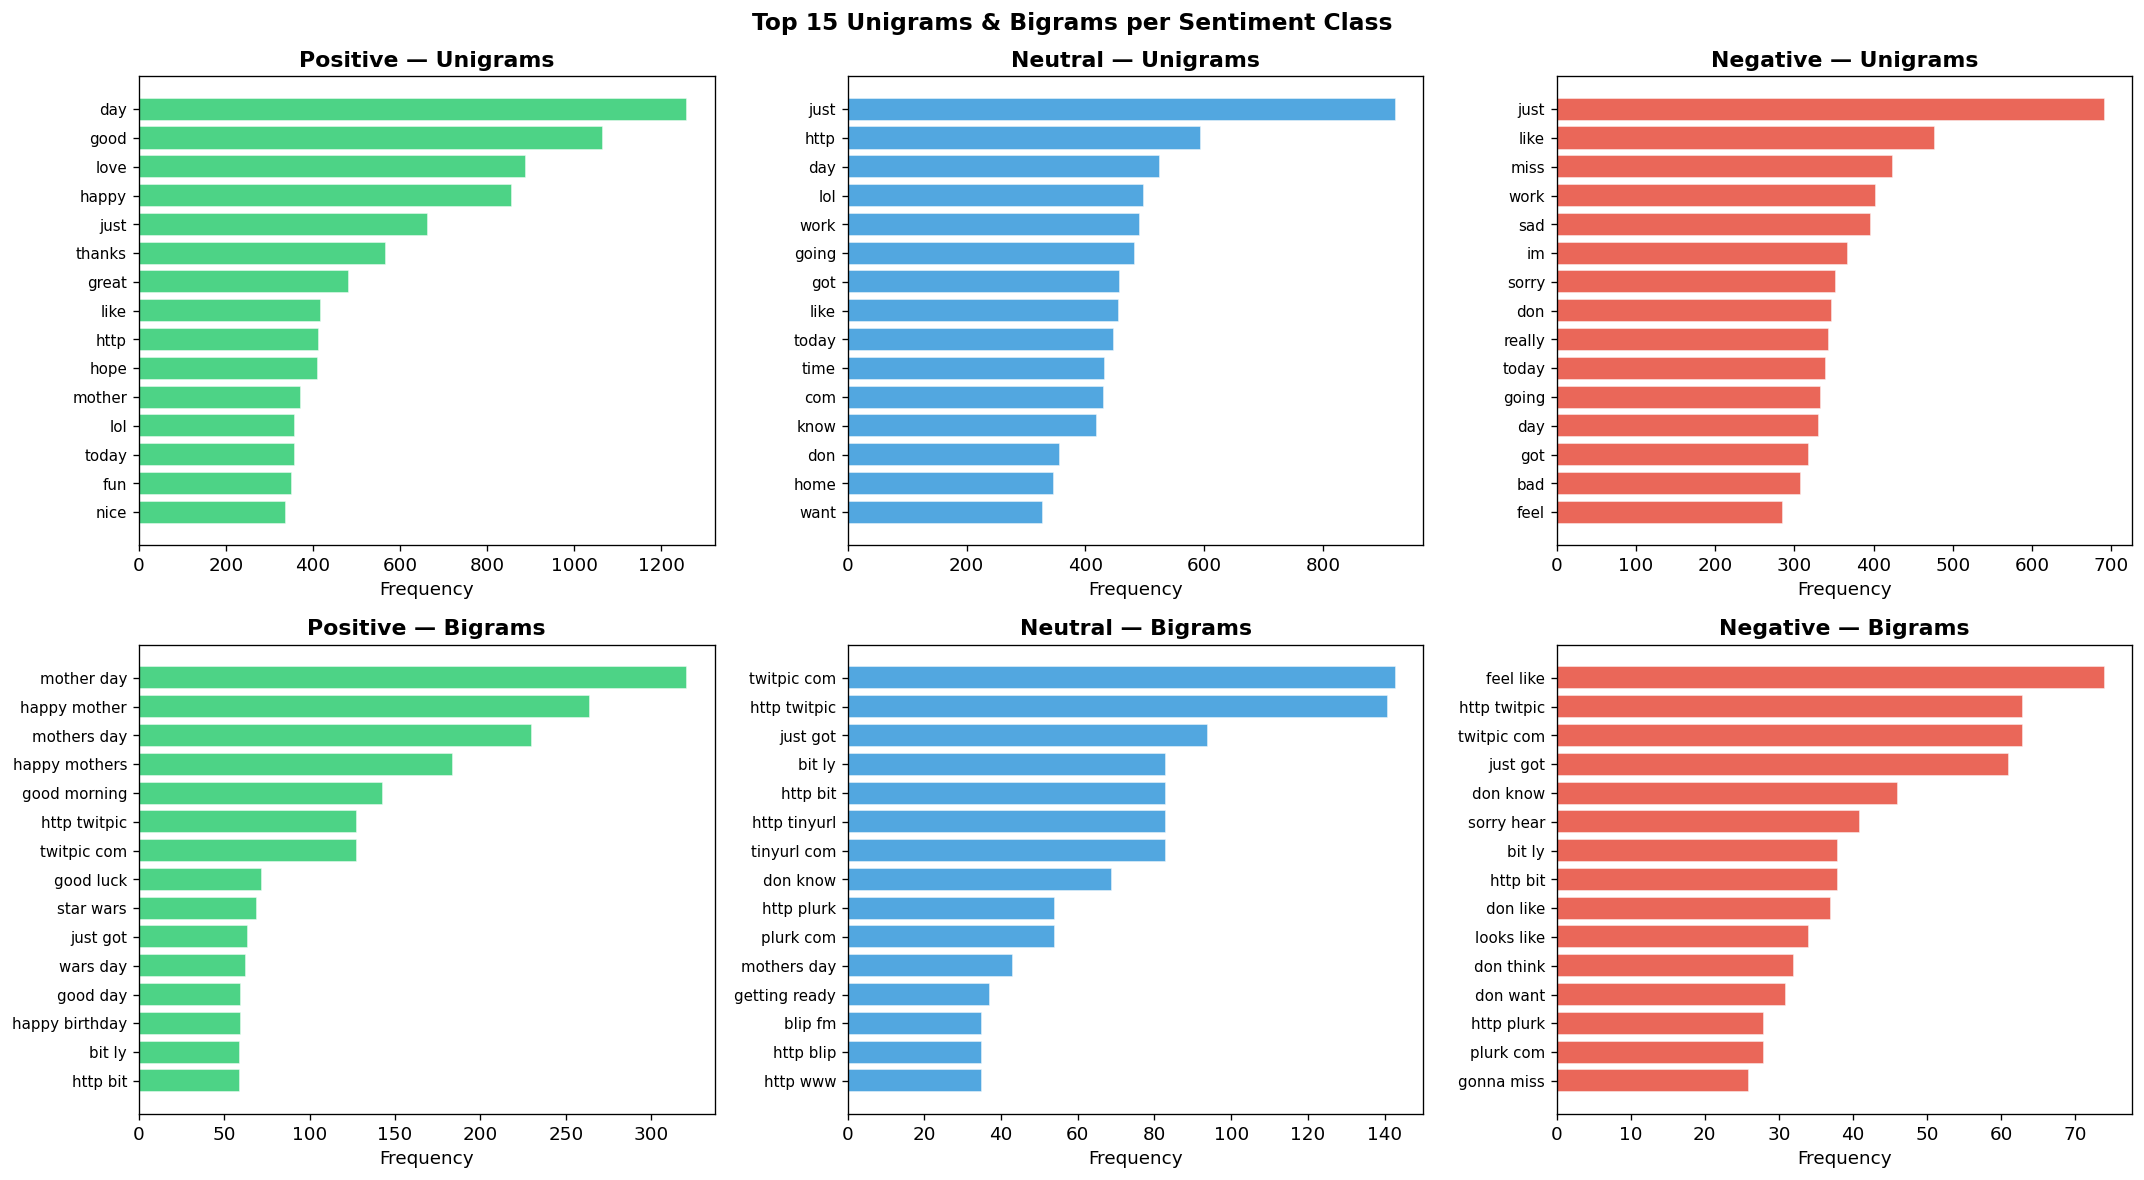

In [11]:
# ── 3.5  Top N-grams (unigrams + bigrams) per class ──────────────────────────
from sklearn.feature_extraction.text import CountVectorizer

def top_ngrams(texts, n=1, top_k=15):
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english',
                          max_features=5000, min_df=2)
    X = vec.fit_transform(texts.astype(str))
    counts = X.sum(axis=0).A1
    vocab  = vec.get_feature_names_out()
    top    = sorted(zip(vocab, counts), key=lambda x: -x[1])[:top_k]
    return pd.DataFrame(top, columns=['ngram', 'count'])

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Top 15 Unigrams & Bigrams per Sentiment Class', fontsize=14, fontweight='bold')

for col_idx, lbl in enumerate(['positive', 'neutral', 'negative']):
    subset = eda_df[eda_df['label'] == lbl][TEXT_COL]
    for row_idx, (n, title) in enumerate([(1, 'Unigrams'), (2, 'Bigrams')]):
        df_ng = top_ngrams(subset, n=n)
        ax = axes[row_idx, col_idx]
        ax.barh(df_ng['ngram'][::-1], df_ng['count'][::-1],
                color=PALETTE[lbl], alpha=0.85, edgecolor='white')
        ax.set_title(f'{lbl.capitalize()} — {title}', fontweight='bold')
        ax.set_xlabel('Frequency')
        ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('eda_ngrams.png', bbox_inches='tight', dpi=130)
plt.show()

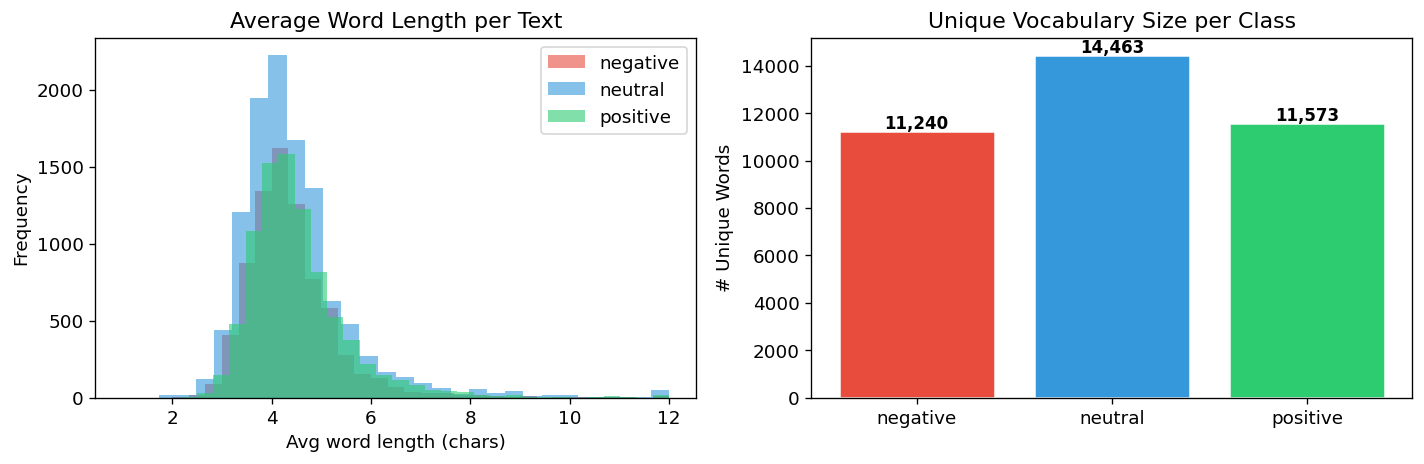

In [12]:
# ── 3.6  Average word length & unique vocabulary per class ───────────────────
eda_df['avg_word_len'] = eda_df[TEXT_COL].astype(str).apply(
    lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Avg word length distribution
for lbl, grp in eda_df.groupby('label'):
    axes[0].hist(grp['avg_word_len'].clip(upper=12), bins=30,
                 alpha=0.6, label=lbl, color=PALETTE[lbl])
axes[0].set_title('Average Word Length per Text')
axes[0].set_xlabel('Avg word length (chars)'); axes[0].set_ylabel('Frequency')
axes[0].legend()

# Unique vocabulary size per class
vocab_sizes = {}
for lbl, grp in eda_df.groupby('label'):
    words = set()
    for t in grp[TEXT_COL].astype(str):
        words.update(re.sub(r'[^a-z ]', ' ', t.lower()).split())
    vocab_sizes[lbl] = len(words)

axes[1].bar(vocab_sizes.keys(), vocab_sizes.values(),
            color=[PALETTE[l] for l in vocab_sizes], edgecolor='white', linewidth=1.5)
axes[1].set_title('Unique Vocabulary Size per Class')
axes[1].set_ylabel('# Unique Words')
for i, (lbl, val) in enumerate(vocab_sizes.items()):
    axes[1].text(i, val + 100, f'{val:,}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('eda_vocab.png', bbox_inches='tight', dpi=130)
plt.show()

---
## 4 · Preprocessing & Cleaning

In [13]:
CLASSES  = ['negative', 'neutral', 'positive']
label2id = {c: i for i, c in enumerate(CLASSES)}
id2label = {i: c for i, c in enumerate(CLASSES)}

def clean_text(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+', '', text)  # remove URLs
    text = re.sub(r'@\w+|#\w+', '', text)        # remove mentions/hashtags
    text = re.sub(r'[^\w\s!?.,]', ' ', text)     # keep light punctuation
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def prepare(df, has_labels=True):
    df = df[[TEXT_COL] + ([LABEL_COL] if has_labels and LABEL_COL in df.columns else [])].dropna().copy()
    df['text'] = df[TEXT_COL].apply(clean_text)
    df = df[df['text'].str.strip() != '']
    if has_labels and LABEL_COL in df.columns:
        df['label']    = df[LABEL_COL].apply(normalise_label)
        df['label_id'] = df['label'].map(label2id)
    return df.reset_index(drop=True)

df_train = prepare(df_raw_train)
df_test  = prepare(df_raw_test)

print(f'Train : {len(df_train):,}  |  Test : {len(df_test):,}')
print('\nTrain label distribution after cleaning:')
print(df_train['label'].value_counts())

Train : 27,476  |  Test : 3,533

Train label distribution after cleaning:
label
neutral     11114
positive     8582
negative     7780
Name: count, dtype: int64


---
## 5 · Baseline — TF-IDF + Logistic Regression

Establishes a **baseline** to measure how much the transformer gains.

In [14]:
from sklearn.pipeline          import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model      import LogisticRegression
from sklearn.metrics           import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing     import label_binarize

MAX_TRAIN = 8000
MAX_TEST  = 2000

df_tr = df_train.sample(n=min(MAX_TRAIN, len(df_train)), random_state=42)
df_te = df_test.sample(n=min(MAX_TEST,  len(df_test)),  random_state=42)

baseline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=30000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        strip_accents='unicode'
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        C=5.0,
        solver='lbfgs',
        multi_class='multinomial',
        random_state=42
    ))
])

baseline.fit(df_tr['text'], df_tr['label'])
y_pred_base = baseline.predict(df_te['text'])

print('=' * 60)
print('  BASELINE — TF-IDF + Logistic Regression')
print('=' * 60)
print(classification_report(df_te['label'], y_pred_base, target_names=CLASSES, digits=4))

  BASELINE — TF-IDF + Logistic Regression
              precision    recall  f1-score   support

    negative     0.6367    0.6843    0.6596       548
     neutral     0.6325    0.6010    0.6163       822
    positive     0.7190    0.7190    0.7190       630

    accuracy                         0.6610      2000
   macro avg     0.6627    0.6681    0.6650      2000
weighted avg     0.6609    0.6610    0.6606      2000



---
## 6 · Tokenise with DistilBERT

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer: distilbert-base-uncased
   Vocab size: 30,522

Token length stats (1000 samples):
  mean=19.6  median=19  p95=35  max=53


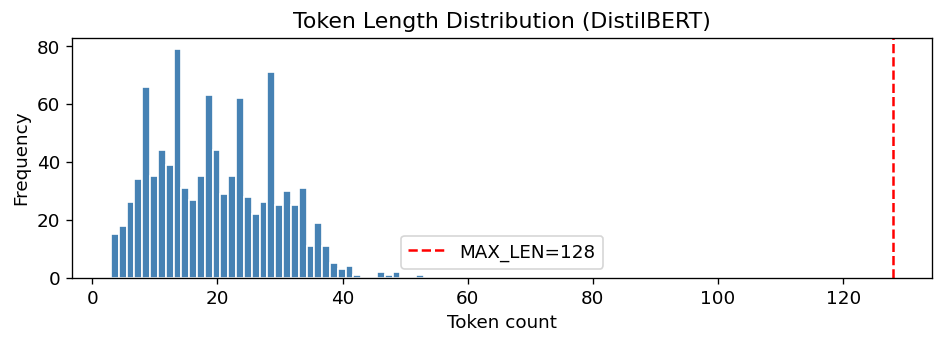

In [15]:
import torch
from torch.utils.data import Dataset
from transformers import AutoTokenizer

MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN    = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'Tokenizer: {MODEL_NAME}')
print(f'   Vocab size: {tokenizer.vocab_size:,}')

# Token length distribution
sample_lens = [
    len(tokenizer(t, truncation=False)['input_ids'])
    for t in df_tr['text'].sample(1000, random_state=42)
]
print(f'\nToken length stats (1000 samples):')
print(f'  mean={np.mean(sample_lens):.1f}  median={np.median(sample_lens):.0f}  '
      f'p95={np.percentile(sample_lens, 95):.0f}  max={max(sample_lens)}')

plt.figure(figsize=(8, 3))
plt.hist(sample_lens, bins=40, color='steelblue', edgecolor='white')
plt.axvline(MAX_LEN, color='red', linestyle='--', label=f'MAX_LEN={MAX_LEN}')
plt.title('Token Length Distribution (DistilBERT)')
plt.xlabel('Token count'); plt.ylabel('Frequency'); plt.legend()
plt.tight_layout(); plt.show()

In [16]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = SentimentDataset(
    df_tr['text'].tolist(), df_tr['label_id'].tolist(), tokenizer, MAX_LEN)
test_dataset = SentimentDataset(
    df_te['text'].tolist(), df_te['label_id'].tolist(), tokenizer, MAX_LEN)

print(f'Train dataset : {len(train_dataset):,} samples')
print(f'Test  dataset : {len(test_dataset):,} samples')

Train dataset : 8,000 samples
Test  dataset : 2,000 samples


---
## 7 · Fine-tune DistilBERT

Advanced training with:
- **Class-weighted loss** to handle imbalance
- **Cosine LR scheduler with warmup**
- **fp16 mixed precision**
- **Best-model checkpointing**

In [17]:
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)
import evaluate

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=id2label, label2id=label2id
)
print(f'Model loaded | Params: {sum(p.numel() for p in model.parameters()):,}')

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded | Params: 66,955,779


In [18]:
# ── Class weights (inverse frequency) ───────────────────────────────────────
from sklearn.utils.class_weight import compute_class_weight

cw = compute_class_weight(
    class_weight='balanced',
    classes=np.array(list(label2id.values())),
    y=df_tr['label_id'].values
)
class_weights = torch.tensor(cw, dtype=torch.float)
print('Class weights:', {id2label[i]: round(w, 3) for i, w in enumerate(cw)})

Class weights: {'negative': np.float64(1.158), 'neutral': np.float64(0.823), 'positive': np.float64(1.085)}


In [19]:
# ── Custom Trainer with weighted CrossEntropyLoss ────────────────────────────
from torch.nn import CrossEntropyLoss

accuracy_metric = evaluate.load('accuracy')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=preds, references=labels)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        logits  = outputs.logits
        loss_fn = CrossEntropyLoss(
            weight=class_weights.to(logits.device)
        )
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

In [20]:
# ── Training arguments ────────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir                  = './results',
    num_train_epochs            = 4,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 64,
    warmup_ratio                = 0.1,          # 10% warmup
    weight_decay                = 0.01,
    learning_rate               = 2e-5,
    lr_scheduler_type           = 'cosine',     # cosine decay
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'accuracy',
    greater_is_better           = True,
    logging_steps               = 50,
    fp16                        = True,
    report_to                   = 'none',
    seed                        = 42
)

trainer = WeightedTrainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = test_dataset,
    compute_metrics = compute_metrics,
)
print(' Trainer ready. Starting fine-tuning...')

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


 Trainer ready. Starting fine-tuning...


In [21]:
train_result = trainer.train()
print(f'\n Training complete!')
print(f'   Loss     : {train_result.training_loss:.4f}')
print(f'   Steps    : {train_result.global_step}')
print(f'   Time (s) : {train_result.metrics["train_runtime"]:.1f}')

Epoch,Training Loss,Validation Loss,Accuracy
1,0.615383,0.580183,0.752500
2,0.479314,0.571932,0.756000
3,0.361430,0.582293,0.772500
4,0.317294,0.596442,0.770000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



 Training complete!
   Loss     : 0.5035
   Steps    : 1000
   Time (s) : 144.1


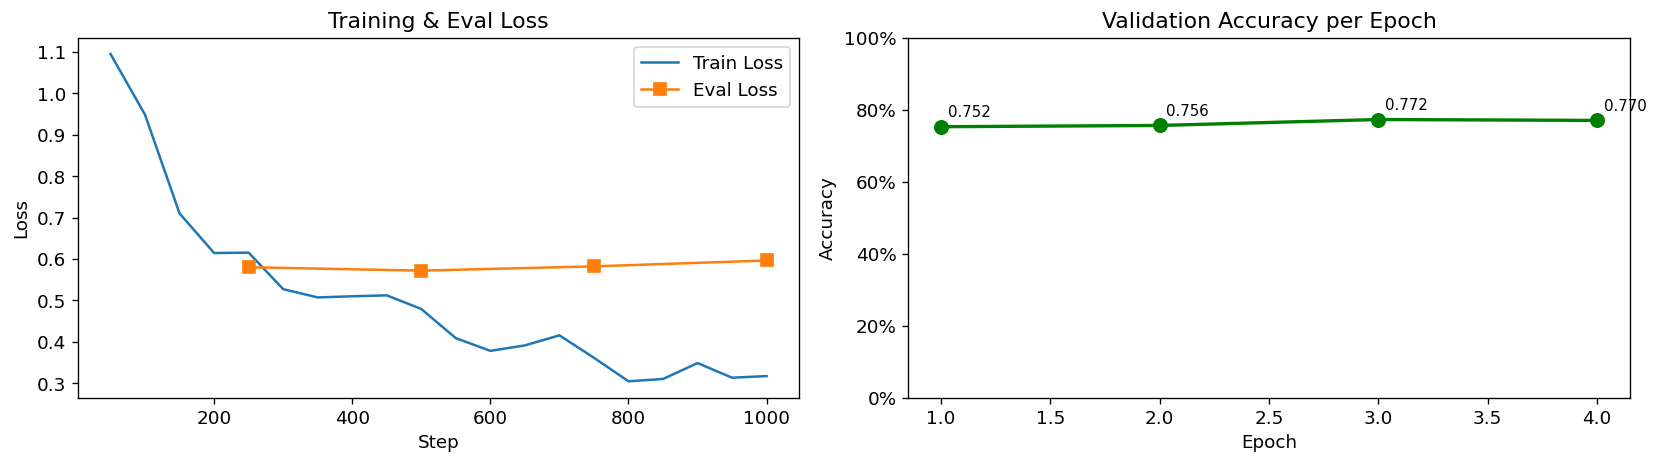

In [22]:
# ── Training & eval loss curve ────────────────────────────────────────────────
log_history  = trainer.state.log_history
train_logs   = [x for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_logs    = [x for x in log_history if 'eval_loss' in x]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss
axes[0].plot([x['step'] for x in train_logs],
             [x['loss']      for x in train_logs], label='Train Loss', linewidth=1.5)
if eval_logs:
    axes[0].plot([x['step']      for x in eval_logs],
                 [x['eval_loss'] for x in eval_logs],
                 marker='s', markersize=7, label='Eval Loss', linewidth=1.5)
axes[0].set_xlabel('Step'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Eval Loss'); axes[0].legend()

# Accuracy
if eval_logs and 'eval_accuracy' in eval_logs[0]:
    axes[1].plot([x['epoch']         for x in eval_logs],
                 [x['eval_accuracy'] for x in eval_logs],
                 marker='o', markersize=8, color='green', linewidth=2)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Validation Accuracy per Epoch')
    axes[1].set_ylim(0, 1); axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y:.0%}'))
    for x_ev in eval_logs:
        axes[1].annotate(f'{x_ev["eval_accuracy"]:.3f}',
                         (x_ev['epoch'], x_ev['eval_accuracy']),
                         textcoords='offset points', xytext=(4, 6), fontsize=9)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=130)
plt.show()

---
## 8 ·  Advanced Evaluation

In [23]:
# ── 8.1  Classification Report ───────────────────────────────────────────────
pred_output   = trainer.predict(test_dataset)
y_true        = pred_output.label_ids
y_logits      = pred_output.predictions
y_pred        = np.argmax(y_logits, axis=-1)
y_prob        = torch.softmax(torch.tensor(y_logits), dim=-1).numpy()

print('=' * 65)
print('         DISTILBERT — CLASSIFICATION REPORT')
print('=' * 65)
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

         DISTILBERT — CLASSIFICATION REPORT
              precision    recall  f1-score   support

    negative     0.7513    0.7883    0.7694       548
     neutral     0.7660    0.7007    0.7319       822
    positive     0.7979    0.8524    0.8243       630

    accuracy                         0.7725      2000
   macro avg     0.7717    0.7805    0.7752      2000
weighted avg     0.7720    0.7725    0.7713      2000



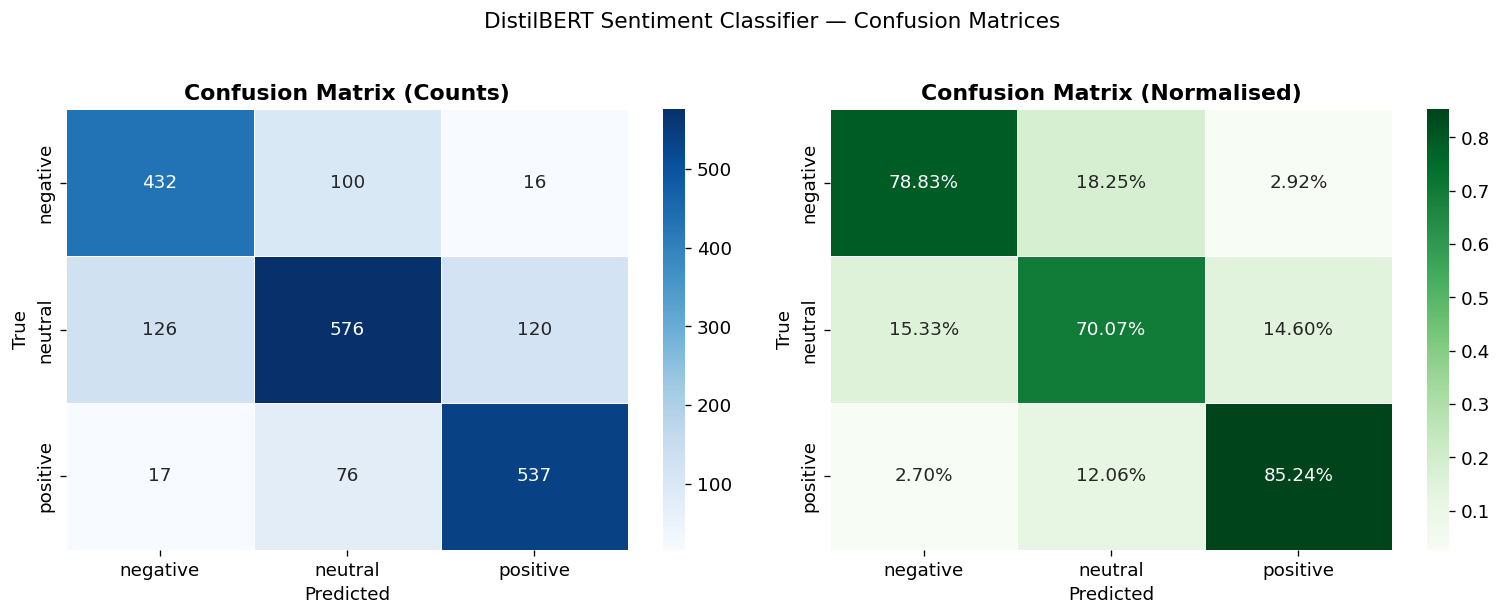

In [24]:
# ── 8.2  Confusion Matrix ────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

# Normalised
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalised)', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.suptitle('DistilBERT Sentiment Classifier — Confusion Matrices', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight', dpi=130)
plt.show()

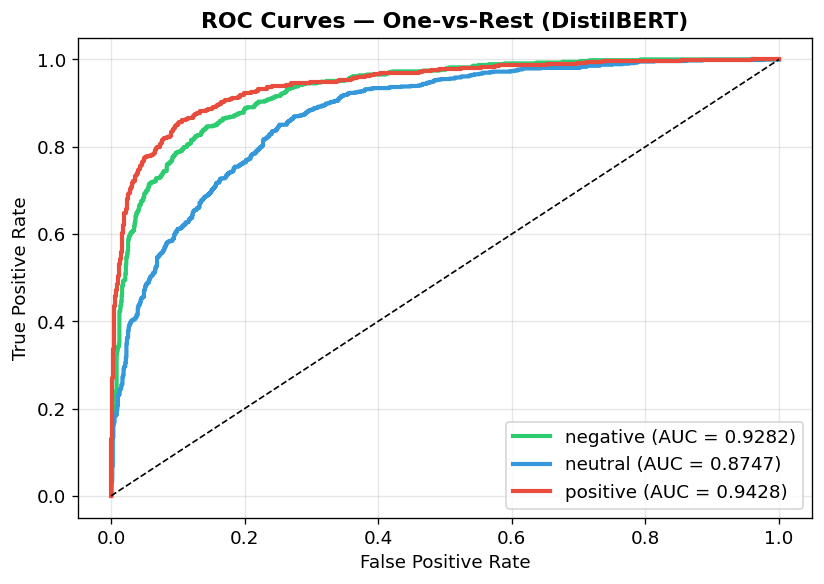

Macro ROC-AUC : 0.9152


In [25]:
# ── 8.3  ROC-AUC Curves (One-vs-Rest) ────────────────────────────────────────
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_bin = label_binarize(y_true, classes=[0, 1, 2])

fig, ax = plt.subplots(figsize=(7, 5))

for i, lbl in enumerate(CLASSES):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2.5,
            color=list(PALETTE.values())[i],
            label=f'{lbl} (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — One-vs-Rest (DistilBERT)', fontweight='bold')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_auc.png', dpi=130)
plt.show()

# Macro AUC
macro_auc = roc_auc_score(y_bin, y_prob, multi_class='ovr', average='macro')
print(f'Macro ROC-AUC : {macro_auc:.4f}')

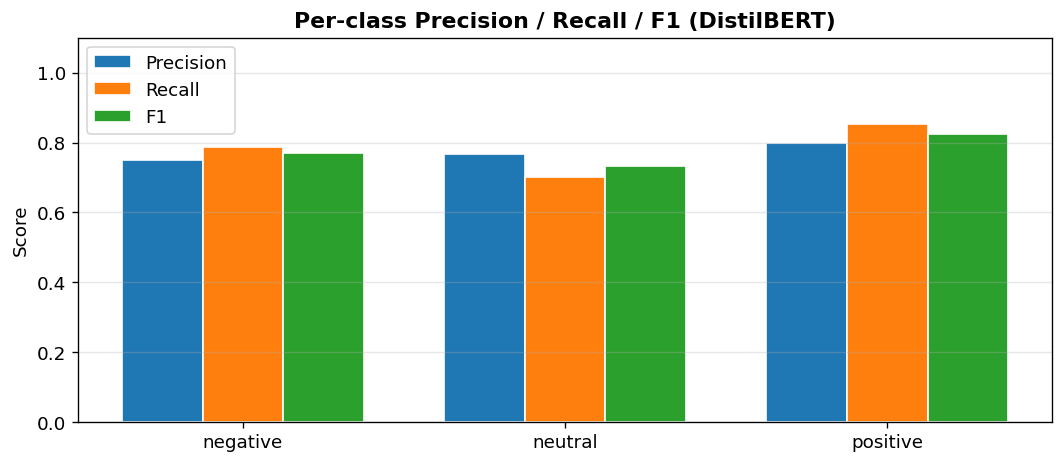

          Precision  Recall      F1
negative     0.7513  0.7883  0.7694
neutral      0.7660  0.7007  0.7319
positive     0.7979  0.8524  0.8243


In [26]:
# ── 8.4  Per-class Precision / Recall / F1 bar chart ────────────────────────
from sklearn.metrics import precision_recall_fscore_support

p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1, 2])
metrics_df  = pd.DataFrame({'Precision': p, 'Recall': r, 'F1': f}, index=CLASSES)

x = np.arange(len(CLASSES))
w = 0.25

fig, ax = plt.subplots(figsize=(9, 4))
for i, (metric, vals) in enumerate(metrics_df.T.iterrows()):
    ax.bar(x + i*w, vals, w, label=metric, edgecolor='white')

ax.set_xticks(x + w); ax.set_xticklabels(CLASSES)
ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
ax.set_title('Per-class Precision / Recall / F1 (DistilBERT)', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_metrics.png', dpi=130)
plt.show()
print(metrics_df.round(4))

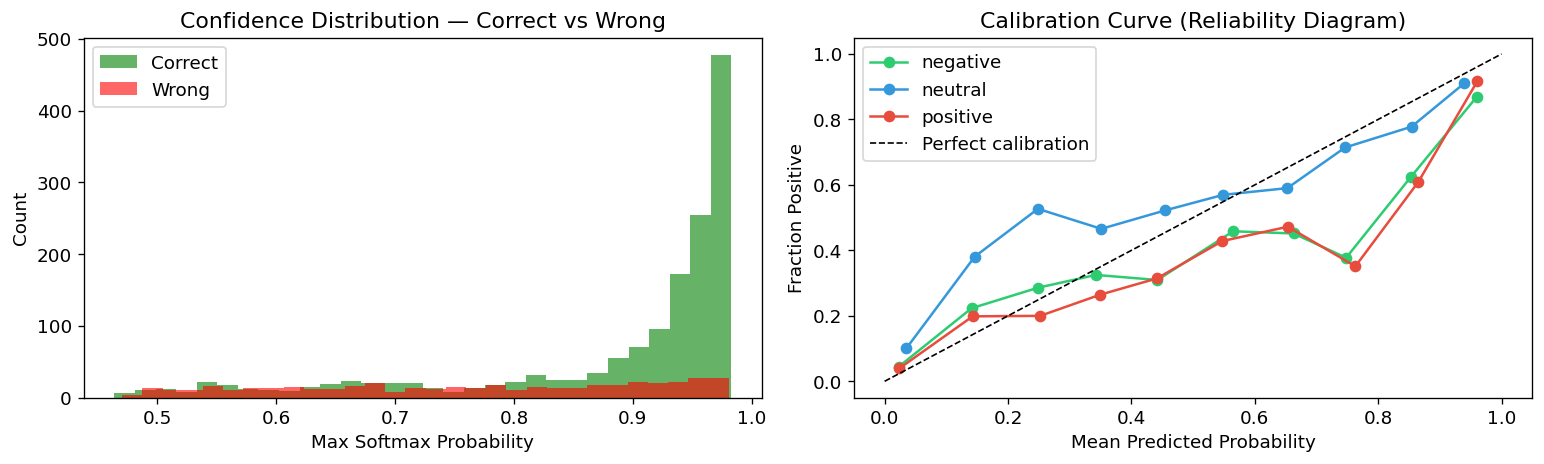

In [27]:
# ── 8.5  Confidence distribution ─────────────────────────────────────────────
max_conf   = y_prob.max(axis=1)
correct    = (y_pred == y_true)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(max_conf[correct],  bins=30, alpha=0.6, color='green', label='Correct')
axes[0].hist(max_conf[~correct], bins=30, alpha=0.6, color='red',   label='Wrong')
axes[0].set_title('Confidence Distribution — Correct vs Wrong')
axes[0].set_xlabel('Max Softmax Probability'); axes[0].set_ylabel('Count')
axes[0].legend()

# Calibration reliability diagram
from sklearn.calibration import calibration_curve
for i, lbl in enumerate(CLASSES):
    frac_pos, mean_pred = calibration_curve(y_bin[:, i], y_prob[:, i], n_bins=10)
    axes[1].plot(mean_pred, frac_pos, marker='o', label=lbl,
                 color=list(PALETTE.values())[i])
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
axes[1].set_title('Calibration Curve (Reliability Diagram)')
axes[1].set_xlabel('Mean Predicted Probability'); axes[1].set_ylabel('Fraction Positive')
axes[1].legend()

plt.tight_layout()
plt.savefig('confidence_calibration.png', dpi=130)
plt.show()

In [28]:
# ── 8.6  Most-Confident Misclassifications ───────────────────────────────────
texts_te  = df_te['text'].tolist()
true_lbls = [id2label[i] for i in y_true]
pred_lbls = [id2label[i] for i in y_pred]

errors_df = pd.DataFrame({
    'text':       texts_te,
    'true':       true_lbls,
    'predicted':  pred_lbls,
    'confidence': max_conf
})
errors_df = errors_df[errors_df['true'] != errors_df['predicted']]
errors_df = errors_df.sort_values('confidence', ascending=False)

print('=' * 70)
print('  TOP 10 MOST-CONFIDENT MISCLASSIFICATIONS')
print('=' * 70)
for _, row in errors_df.head(10).iterrows():
    print(f'  True: {row["true"]:8s} | Pred: {row["predicted"]:8s} | '
          f'Conf: {row["confidence"]*100:.1f}%')
    print(f'  Text: {row["text"][:100]}')
    print()

  TOP 10 MOST-CONFIDENT MISCLASSIFICATIONS
  True: neutral  | Pred: negative | Conf: 98.1%
  Text: My head hurts.... Can wait to see the new photoshoot!!!!!!!

  True: positive | Pred: negative | Conf: 98.0%
  Text: soo stressed out...I think I could possibly lose it

  True: neutral  | Pred: positive | Conf: 97.8%
  Text: ohh snapp, have fun

  True: neutral  | Pred: positive | Conf: 97.7%
  Text: First surprise birthday ever, best night I ve had in a long time!

  True: neutral  | Pred: negative | Conf: 97.6%
  Text: Big Sad Face Bing doesn t work on iPhone. It just takes you to the regular mobile Live search.

  True: neutral  | Pred: negative | Conf: 97.5%
  Text: missin the guys really

  True: neutral  | Pred: positive | Conf: 97.5%
  Text: My younger sister flies in next week for a two week visit. So blessed to look forward to seeing fami

  True: neutral  | Pred: negative | Conf: 97.5%
  Text: curses upon the ridiculously slow internetz at work! The dang image just now loaded..


  MODEL COMPARISON
                     Model  Accuracy  Macro F1  Weighted F1
TF-IDF + LogReg (Baseline)    0.6610    0.6650       0.6606
   DistilBERT (Fine-tuned)    0.7725    0.7752       0.7713


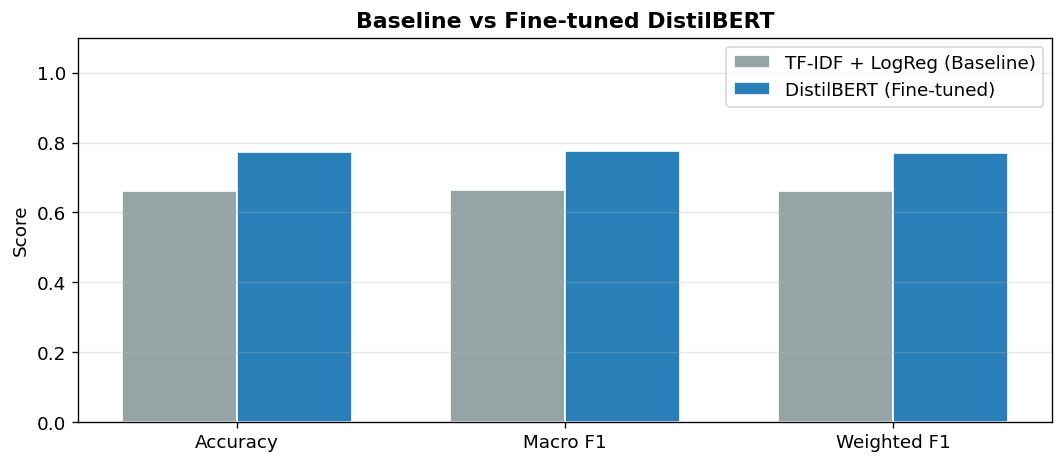

In [29]:
# ── 8.7  Baseline vs Transformer comparison table ────────────────────────────
from sklearn.metrics import accuracy_score, f1_score

y_true_lbl = [id2label[i] for i in y_true]

results = pd.DataFrame({
    'Model': ['TF-IDF + LogReg (Baseline)', 'DistilBERT (Fine-tuned)'],
    'Accuracy': [
        accuracy_score(df_te['label'], y_pred_base),
        accuracy_score(y_true_lbl, pred_lbls)
    ],
    'Macro F1': [
        f1_score(df_te['label'], y_pred_base, average='macro'),
        f1_score(y_true_lbl, pred_lbls,       average='macro')
    ],
    'Weighted F1': [
        f1_score(df_te['label'], y_pred_base, average='weighted'),
        f1_score(y_true_lbl, pred_lbls,       average='weighted')
    ]
})

results[['Accuracy','Macro F1','Weighted F1']] = \
    results[['Accuracy','Macro F1','Weighted F1']].applymap(lambda x: round(x, 4))

print('\n' + '=' * 60)
print('  MODEL COMPARISON')
print('=' * 60)
print(results.to_string(index=False))

# Visual comparison
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(3)
metrics = ['Accuracy', 'Macro F1', 'Weighted F1']
colors  = ['#95a5a6', '#2980b9']
for i, row in results.iterrows():
    ax.bar(x + i*0.35, row[metrics].values, 0.35,
           label=row['Model'], color=colors[i], edgecolor='white')
ax.set_xticks(x + 0.175); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
ax.set_title('Baseline vs Fine-tuned DistilBERT', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=130)
plt.show()

In [32]:
import torch

# ── 9.2  Interactive inference function ─────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
def predict_sentiment(texts):
    """Returns sentiment + confidence for a list of texts."""
    enc = tokenizer(texts, max_length=MAX_LEN, padding='max_length',
                    truncation=True, return_tensors='pt').to(device)
    with torch.no_grad():
        logits = model(**enc).logits
    probs = torch.softmax(logits, dim=-1).cpu().numpy()
    preds = probs.argmax(axis=-1)
    return [
        {
            'text':       t,
            'sentiment':  id2label[p],
            'confidence': round(probs[i][p] * 100, 2),
            'scores':     {id2label[j]: round(float(probs[i][j])*100, 2) for j in range(3)}
        }
        for i, (t, p) in enumerate(zip(texts, preds))
    ]

test_texts = [
    "This is genuinely the best product I have ever bought!",
    "The package arrived on time and nothing was damaged.",
    "Completely useless, would never recommend this to anyone.",
    "An okay experience — nothing spectacular but no complaints."
]

print('\n── Inference Results ─────────────────────────────────────')
for r in predict_sentiment(test_texts):
    print(f'\n  Sentiment : {r["sentiment"].upper()} ({r["confidence"]}%)')
    print(f'  Scores    : { {k: str(v)+"%" for k, v in r["scores"].items()} }')
    print(f'  Text      : {r["text"]}')


── Inference Results ─────────────────────────────────────

  Sentiment : POSITIVE (97.83999633789062%)
  Scores    : {'negative': '0.59%', 'neutral': '1.57%', 'positive': '97.84%'}
  Text      : This is genuinely the best product I have ever bought!

  Sentiment : POSITIVE (58.349998474121094%)
  Scores    : {'negative': '4.98%', 'neutral': '36.67%', 'positive': '58.35%'}
  Text      : The package arrived on time and nothing was damaged.

  Sentiment : NEGATIVE (96.12999725341797%)
  Scores    : {'negative': '96.13%', 'neutral': '3.14%', 'positive': '0.74%'}
  Text      : Completely useless, would never recommend this to anyone.

  Sentiment : POSITIVE (94.79000091552734%)
  Scores    : {'negative': '0.74%', 'neutral': '4.47%', 'positive': '94.79%'}
  Text      : An okay experience — nothing spectacular but no complaints.


In [33]:
# ── 9.3  Save fine-tuned model ───────────────────────────────────────────────
SAVE_PATH = './fine_tuned_distilbert_sentiment'
model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print(f' Fine-tuned model saved → {SAVE_PATH}')

# Optional: download as zip
# import shutil
# from google.colab import files
# shutil.make_archive('model', 'zip', SAVE_PATH)
# files.download('model.zip')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 Fine-tuned model saved → ./fine_tuned_distilbert_sentiment


## Summary of Sentiment Analysis Project

This notebook provides a comprehensive walkthrough of a sentiment analysis project, from data loading and exploratory data analysis (EDA) to model training, evaluation, and interactive inference.

### 1. Setup & Data Loading

- Essential libraries such as `transformers`, `datasets`, `nltk`, `scikit-learn`, `matplotlib`, `seaborn`, and `wordcloud` were installed and imported.
- NLTK stopwords and WordNetLemmatizer were downloaded for text preprocessing.
- The sentiment analysis dataset was downloaded from Kaggle using the Kaggle API.
- The raw train and test datasets were loaded into pandas DataFrames, handling various encodings. The text and sentiment label columns were automatically detected.

### 2. Exploratory Data Analysis (EDA)

- **Missing Values & Basic Stats**: The dataset was inspected for missing values and general statistics. One missing value in the 'text' and 'selected_text' columns of the training data was noted.
- **Label Distribution**: Sentiment labels ('positive', 'neutral', 'negative') were normalized and their distribution was visualized using bar and pie charts. It was observed that 'neutral' sentiment was the most prevalent, leading to a slight class imbalance (imbalance ratio of 1.43x).
- **Text-Length Analysis**: Distributions of character and word counts were plotted for each sentiment class. Box plots and violin plots further detailed these distributions, showing similar text lengths across sentiment categories.
- **Word Clouds**: Word clouds were generated for each sentiment class, providing a visual representation of the most frequent words in positive, neutral, and negative texts.
- **Top N-grams**: Top unigrams and bigrams were extracted and visualized per sentiment class, revealing common phrases and single words associated with each sentiment.
- **Average Word Length & Unique Vocabulary**: Distributions of average word length per text were plotted, and the unique vocabulary size for each class was calculated and displayed.

### 3. Preprocessing & Cleaning

- A `clean_text` function was defined to remove URLs, mentions/hashtags, and normalize whitespace. Light punctuation was retained.
- A `prepare` function was created to apply the cleaning steps, map sentiment labels to numerical IDs, and remove rows with empty text after cleaning.
- The training and testing datasets were processed, resulting in 27,476 clean training samples and 3,533 clean test samples.

### 4. Baseline Model — TF-IDF + Logistic Regression

- A baseline model was established using a `Pipeline` consisting of `TfidfVectorizer` and `LogisticRegression`.
- A subset of 8,000 training samples and 2,000 test samples was used for training and evaluation.
- The baseline model achieved an **accuracy of 0.6610** and a **macro F1-score of 0.6650**.

### 5. Fine-tune DistilBERT

- **Tokenization**: The `DistilBert-base-uncased` tokenizer was loaded, and the distribution of token lengths was analyzed to determine an appropriate `MAX_LEN` (128).
- **Custom Dataset**: A `SentimentDataset` class was implemented to handle tokenization and prepare data for the DistilBERT model.
- **Model Loading**: `AutoModelForSequenceClassification` was loaded with 3 labels.
- **Class Weights**: Inverse frequency class weights were computed to address the class imbalance observed during EDA.
- **Custom Trainer**: A `WeightedTrainer` was implemented to incorporate class weights into the `CrossEntropyLoss` function during training.
- **Training**: The DistilBERT model was fine-tuned for 4 epochs using specific `TrainingArguments` (e.g., learning rate, warmup ratio, cosine LR scheduler, fp16 mixed precision, best model checkpointing).

### 6. Advanced Evaluation

- **Classification Report**: The fine-tuned DistilBERT model achieved an **accuracy of 0.7725** and a **macro F1-score of 0.7752**, significantly outperforming the baseline.
- **Confusion Matrix**: Visualizations of the confusion matrix (raw counts and normalized) provided insight into per-class classification performance.
- **ROC-AUC Curves**: One-vs-Rest ROC curves were plotted for each class, with a **macro ROC-AUC of 0.9152**.
- **Per-class Metrics Bar Chart**: A bar chart displayed per-class precision, recall, and F1-scores, showing strong performance across all sentiment categories.
- **Confidence Distribution & Misclassifications**: Histograms of prediction confidence for correct and wrong predictions were analyzed. Calibration curves showed how well predicted probabilities matched actual outcomes. The top 10 most confident misclassifications were printed to understand challenging cases.

### 7. Model Comparison & Inference

- A comparison table and bar chart clearly demonstrated the superior performance of the fine-tuned DistilBERT model over the TF-IDF + Logistic Regression baseline across accuracy, macro F1, and weighted F1 scores.
- An interactive `predict_sentiment` function was provided for real-time inference on new texts, showcasing the model's ability to classify sentiment and provide confidence scores.
- The fine-tuned DistilBERT model and its tokenizer were saved locally for future use.